In [1]:
import numpy as np
import cupy as cp

In [2]:
import libertem.api as lt

In [3]:
import matplotlib.pyplot as plt

In [4]:
from libertem.udf import UDF

In [5]:
%matplotlib widget

In [ ]:
class PositionAverageSig(UDF):
        
    def get_result_buffers(self):
        return {
            'sumSig': self.buffer(kind='sig', dtype='float32'),
            'num_frames': self.buffer(kind='single', dtype='int64'),
            'meanSig': self.buffer(kind='sig', dtype='float32', use='result_only'),
        }

    def process_frame(self, frame):
        self.results.sumSig[:] += frame
        self.results.num_frames[:] += 1

    def merge(self, dest, src):
        dest.sumSig[:] += src.sumSig
        dest.num_frames[:] += src.num_frames

    def get_results(self):
        return {
            'meanSig': self.results.sumSig / self.results.num_frames[:],
        }

In [7]:
## Need additional
class VirtualFieldImaging(UDF):
    def get_backends(self):
                # Support all recommended array backends in LiberTEM.
                # Please note that their APIs can differ so that comprehensive
                # tests with all supported backends are required. Also, the list of
                # supported backends in LiberTEM may grow in the future, which can
                # require adaptations in an UDF that uses this constant.
            return self.BACKEND_ALL
            
    def get_result_buffers(self):
        return {
            'sum_of_pixels': self.buffer(kind='nav', dtype=self.xp.float32, where='device')
        }

    def process_frame(self, frame):
        self.results.sum_of_pixels[:] = self.xp.sum(frame)

In [8]:
import os

In [9]:
data_dir = r"D:\CrSBr\20260816_CrSBr_Strain\4_CL10um"

In [10]:
file_path = os.path.join(data_dir, "STEM SI.dm4")
file_path

'D:\\CrSBr\\20260816_CrSBr_Strain\\4_CL10um\\STEM SI.dm4'

In [11]:
out_dir = os.path.join(data_dir, "outputs")
if not os.path.exists(out_dir):
    os.makedirs(out_dir)
out_dir

'D:\\CrSBr\\20260816_CrSBr_Strain\\4_CL10um\\outputs'

In [12]:
ctx = lt.Context()

2026-08-21 11:47:23,815 - distributed.scheduler - WARNING - Removing worker 'tcp://10.7.158.158:51204' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {'_run_task-f168737d-79ba-4212-b0f9-6b605720006b'} (stimulus_id='handle-worker-cleanup-1787327243.8150344')
2026-08-21 11:47:23,956 - distributed.scheduler - WARNING - Received heartbeat from unregistered worker 'tcp://10.7.158.158:51204'.
2026-08-21 11:47:43,066 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing


In [13]:
data = ctx.load("dm", file_path, dataset_index = 3)
data

<DMFileDataset D:\CrSBr\20260816_CrSBr_Strain\4_CL10um\STEM SI.dm4> - (99, 752, 128, 128)

In [14]:
res_panbd = ctx.run_udf(dataset=data, udf=PositionAverageDP(), progress = True)

Partitions 0/16, Frames:   0%|          | 0/74448 [00:00<?, ?it/s]

In [15]:
res_pixelsum_2 = ctx.run_udf(dataset=data, udf=VirtualFieldImaging(), backends=('numpy',), progress=True)


Partitions 0/16, Frames:   0%|          | 0/74448 [00:00<?, ?it/s]

# Calculate Cepstrum

In [16]:
class CalculateCepstrum(UDF):
    def get_backends(self):
        return self.BACKEND_ALL

    def __init__(self, window = True, pad = True, pad_shape = (1024, 1024), output_shape = (128, 128), *args, **kwargs):
        """
        Cepstrum transform
        parameters
        window : Bool
            If true, a hann window will be applied

        pad : Bool
            If True, the input will be padded

        pad_shape : int
            If pad = True, pad_width specifies the padded frame size

        output_shape : int
            Specify the output shape
        ----------
        """
        super().__init__(*args, window = window, pad = pad, pad_shape = pad_shape, output_shape = output_shape)

    def get_result_buffers(self):
        return {
            "cepstrum": self.buffer(kind = 'nav', dtype = self.xp.int16, extra_shape = self.params.output_shape, where = 'device')
        }

    def process_frame(self, frame):
        output_shape = self.params.output_shape
        sx, sy = self.meta.dataset_shape[2], self.meta.dataset_shape[3]

        frame[frame<1] = 1

        if self.params.window: # Create Windowing
            xx, yy = self.xp.mgrid[0:sx,0:sy]
            w = (1/2-1/2*self.xp.cos(2*self.xp.pi*xx/sx))*(1/2-1/2*self.xp.cos(2*self.xp.pi*yy/sy))


        if self.params.pad and self.params.pad_shape:
            pad_width = ((self.params.pad_shape[0] - sx)//2, (self.params.pad_shape[1] - sy)//2)

        else:
            pad_width = ((0, 0), (0, 0))


        dp_log = self.xp.log(frame)
        dp_pad = self.xp.pad(dp_log*w, pad_width, mode='constant', constant_values=0)

        ceps = self.xp.abs(self.xp.fft.fftshift(self.xp.fft.fft2(self.xp.fft.ifftshift(dp_pad))))
        ceps = ceps[ceps.shape[0]//2 - output_shape[0]//2 : ceps.shape[0]//2 + output_shape[0]//2, ceps.shape[1]//2 - output_shape[1]//2 : ceps.shape[1]//2 + output_shape[1]//2]

        t = self.xp.percentile(ceps,99.99)
        ceps[ceps>t] = t
        ceps = (ceps - ceps.min())/(ceps.max() - ceps.min())*32767


        self.results.cepstrum[:] = ceps.astype("int16")


In [25]:
cepstrum = ctx.run_udf(dataset=data, udf=CalculateCepstrum(window = True, pad = True, pad_shape = (256,256), output_shape = (128, 128)), backends=('numpy',), progress=True)

Partitions 0/16, Frames:   0%|          | 0/74448 [00:00<?, ?it/s]

In [26]:
np.save(os.path.join(out_dir, 'cepstrum.npy'), cepstrum['cepstrum'].data)

In [27]:
ctx.close()

2026-08-21 11:54:59,279 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing


# Analyze Cepstrum peak positions using CoM

In [64]:
from scipy.ndimage import gaussian_filter as gaussian

In [35]:
ctx = lt.Context()

In [36]:
cepstrum = ctx.load("npy", os.path.join(out_dir, 'cepstrum.npy'))

In [37]:
PosAvgCeps = ctx.run_udf(dataset=cepstrum, udf=PositionAverageDP(), progress = True)

Partitions 0/16, Frames:   0%|          | 0/74448 [00:00<?, ?it/s]

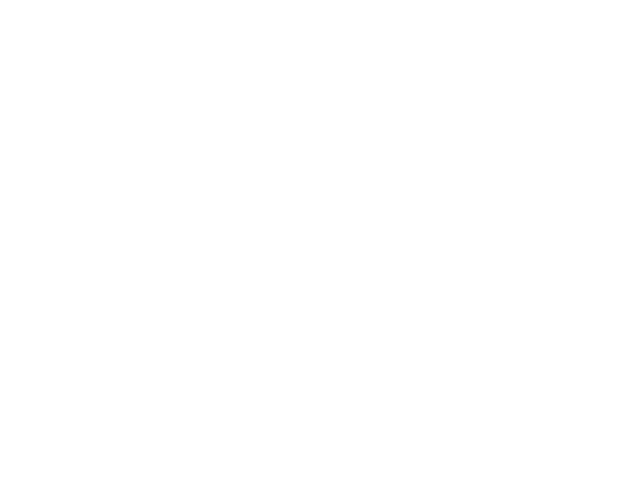

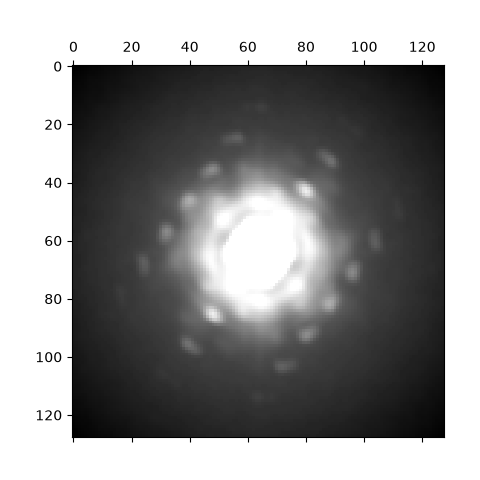

In [ ]:
plt.figure()
plt.matshow(PosAvgCeps['meanDP'].data, cmap='gray', vmax =5e2, norm = 'log')

In [46]:
class FindSigCenterCoM(UDF):
    def __init__(self, c_row, c_column, rin, rout = None, *args, **kwargs):
        """
        Find 4D-STEM Disk Deflection using Center-of-mass method
        parameters
        ----------
        """
        if rout is None:
            rout = 1000

        super().__init__(*args,c_row = c_row, c_column = c_column, rin = rin, rout = rout)

    def get_result_buffers(self):
        return {
            "center": self.buffer(kind = 'nav', dtype = self.xp.float64, extra_shape = (2,))
        }

    def process_frame(self, frame):
        cr, cc, rin, rout = self.params.c_row, self.params.c_column, self.params.rin, self.params.rout
        sr, sc = self.meta.dataset_shape[2], self.meta.dataset_shape[3]

        srr, scc = np.mgrid[0:sr, 0:sc]
        mask = ((srr - cr)**2 + (scc - cc)**2 < rout**2)&((srr - cr)**2 + (scc - cc)**2 > rin**2)

        com = (self.xp.sum(frame*mask*srr, axis=(0,1)) / self.xp.sum(frame*mask), self.xp.sum(frame*mask*scc, axis=(0,1)) / self.xp.sum(frame*mask))

        self.results.center[:] =  com

In [85]:
com_a_ceps = ctx.run_udf(dataset=cepstrum, udf=FindSigCenterCoM(c_row = 43, c_column = 80, rin = 0, rout = 5), backends=('numpy',), progress=True)

Partitions 0/16, Frames:   0%|          | 0/74448 [00:00<?, ?it/s]

In [86]:
com_c_ceps = ctx.run_udf(dataset=cepstrum, udf=FindSigCenterCoM(c_row = 47, c_column = 40, rin = 0, rout = 5), backends=('numpy',), progress=True)

Partitions 0/16, Frames:   0%|          | 0/74448 [00:00<?, ?it/s]

In [87]:
com_a_ceps = com_a_ceps['center'].data
com_c_ceps = com_c_ceps['center'].data

In [88]:
com_a_ceps.min(), com_a_ceps.max()

(np.float64(41.47881320518178), np.float64(81.56219221124505))

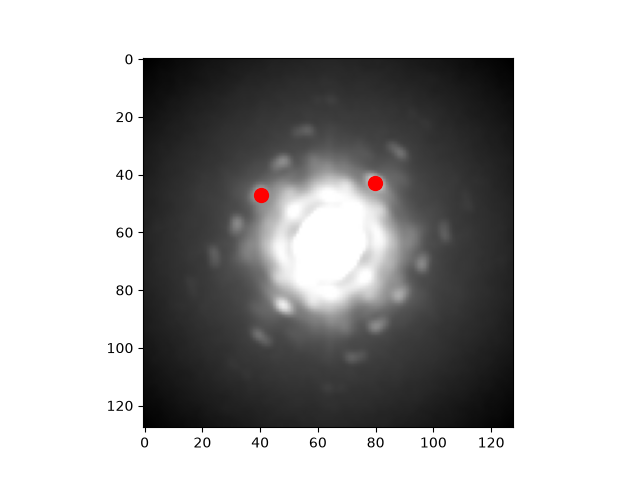

In [89]:
plt.figure()
plt.imshow(PosAvgCeps['meanDP'].data, cmap='gray', vmax =5e2, norm = 'log')
plt.scatter(com_a_ceps[...,1].mean(), com_a_ceps[...,0].mean(), s = 100, c = 'r')
plt.scatter(com_c_ceps[...,1].mean(), com_c_ceps[...,0].mean(), s = 100, c = 'r')

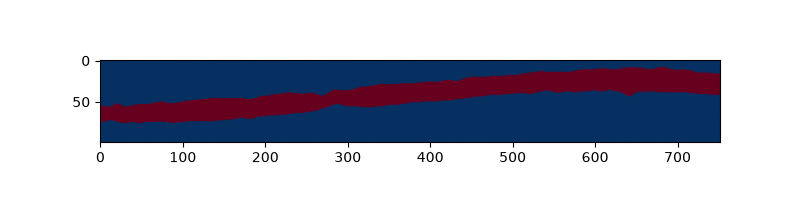

In [109]:
plt.figure(figsize = (8,2))
plt.imshow(gaussian(np.sqrt((com_a_ceps[...,1] - 64)**2 + (com_a_ceps[...,0] - 64)**2), 5)>26.4, cmap = 'RdBu_r')

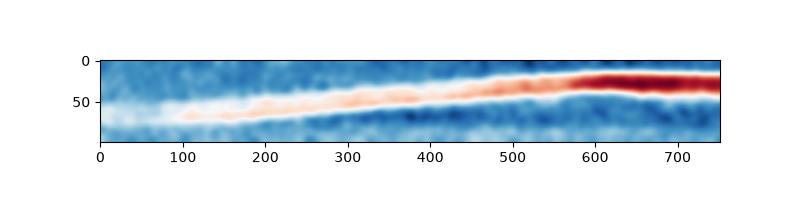

In [91]:
plt.figure(figsize = (8,2))
plt.imshow(gaussian(np.sqrt((com_c_ceps[...,1] - 64)**2 + (com_c_ceps[...,0] - 64)**2), 5), cmap = 'RdBu_r')

In [110]:
sample_mask = gaussian(np.sqrt((com_a_ceps[...,1] - 64)**2 + (com_a_ceps[...,0] - 64)**2), 5)>26.4

In [113]:
ref_a = com_a_ceps[sample_mask].mean((0)) - np.array([64, 64])
ref_c = com_c_ceps[sample_mask].mean((0)) - np.array([64, 64])
ref_a, ref_c

(array([-21.22090961,  15.93870547]), array([-17.24533574, -23.97110309]))

In [99]:
R0 = np.stack([ref_a, ref_c], axis = 1)
R0

array([[-20.94394867, -16.97862997],
       [ 15.91147646, -23.85237493]])

In [93]:
a_vecs = com_a_ceps - np.array([64,64])
c_vecs = com_c_ceps - np.array([64,64])

In [101]:
R = np.stack([a_vecs, c_vecs], axis = -1)
R.shape

(99, 752, 2, 2)

In [94]:
def fit_T(R, R0, weights=None):
    """
    R  : (..., 2, N) measured peak vectors, leading dims = scan grid
    R0 : (2, N) reference vectors
    returns T : (..., 2, 2)
    """
    W = np.eye(R0.shape[1]) if weights is None else np.diag(weights)
    A = R0 @ W @ R0.T                      # (2,2), same for all probes
    return np.einsum('...in,nm,mj->...ij', R, W @ R0.T, np.linalg.inv(A))

def decompose(T, polar=True):
    if polar:
        U_, s, Vt = np.linalg.svd(T)
        Q = U_ @ Vt
        U = (Vt.transpose(*range(Vt.ndim-2), -1, -2) * s[..., None, :]) @ Vt
        eps = U - np.eye(2)
        theta = np.arctan2(Q[..., 1, 0], Q[..., 0, 0])
    else:
        e = T - np.eye(2)
        eps = 0.5 * (e + e.transpose(*range(e.ndim-2), -1, -2))
        theta = 0.5 * (e[..., 1, 0] - e[..., 0, 1])
    return eps[..., 0, 0], eps[..., 1, 1], eps[..., 0, 1], theta

def residual(T, R, R0):
    return np.linalg.norm(R - T @ R0, axis=(-2, -1)) / np.sqrt(R0.shape[1])

In [103]:
T = fit_T(R, R0)
T.shape

(99, 752, 2, 2)

In [104]:
eps_matrices = decompose(T, polar=True)

Text(0.5, 1.0, '$Rotation$')

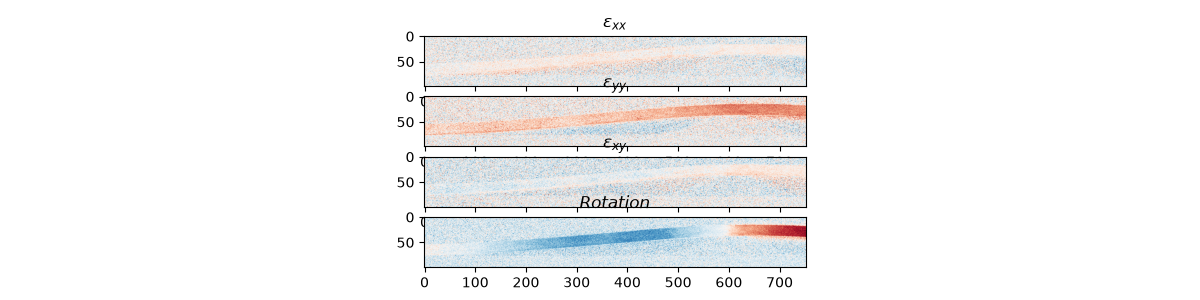

In [107]:
_, axs = plt.subplots(4, 1, figsize=(12, 3))
axs[0].imshow(eps_matrices[1], cmap='RdBu_r')
axs[0].set_title(r'$\epsilon_{xx}$')
axs[1].imshow(eps_matrices[0], cmap='RdBu_r')
axs[1].set_title(r'$\epsilon_{yy}$')

axs[2].imshow(eps_matrices[2], cmap='RdBu_r')
axs[2].set_title(r'$\epsilon_{xy}$')
axs[3].imshow(eps_matrices[3], cmap='RdBu_r')
axs[3].set_title(r'$Rotation$')
